In [1]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

import numpy as np

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


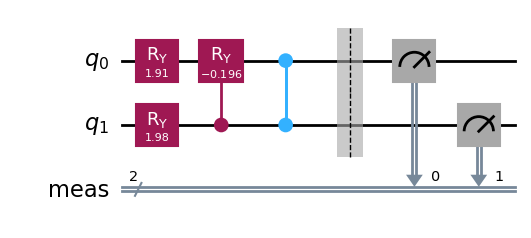

In [2]:
theta1 = 2. * np.arctan(np.sqrt(7./3.))
theta2 = 2. * np.arctan(np.sqrt(2.))
theta3 = 2. * np.arctan(np.sqrt(4./3.))

circuit = QuantumCircuit(2)

circuit.ry(theta1, 1)
circuit.ry(theta2, 0)
circuit.cry(theta3 - theta2, 1, 0)
circuit.cz(0,1)

circuit.measure_all()

circuit.draw("mpl")

In [3]:
sim = AerSimulator()

compiled_circuit = transpile(circuit, sim, optimization_level=0)

job = sim.run(compiled_circuit, shots=100) 
result = job.result()

counts = result.get_counts(compiled_circuit)
print(counts)

{'01': 17, '00': 8, '10': 29, '11': 46}
